# Análisis predictivo de riesgo de devolución en e-commerce

Este notebook conecta con la vista `gold.return_probability_features` en PostgreSQL para construir un modelo de clasificación simple y profesional con el menor código necesario.

In [7]:
# Importación mínima y configuración
import os
import warnings
from pathlib import Path

%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sqlalchemy import create_engine

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid")

# Cargar variables de entorno desde la raíz del proyecto
project_root = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
load_dotenv(project_root / ".env")

# Conexión a PostgreSQL usando únicamente las variables externas del proyecto
engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('EXTERNAL_DB_USER')}:{os.getenv('EXTERNAL_DB_PASSWORD')}"
    f"@{os.getenv('EXTERNAL_DB_HOST')}:{os.getenv('EXTERNAL_DB_PORT')}/{os.getenv('EXTERNAL_DB_NAME')}"
)

query = "SELECT * FROM gold.return_probability_features"
df = pd.read_sql(query, engine)

for col in ["customer_id", "total_orders", "total_returns", "return_rate", "avg_spent"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["total_orders", "total_returns", "return_rate", "avg_spent"]).copy()

print(df.head())
print(f"\nFilas cargadas: {df.shape[0]}")

   customer_id  total_orders  total_returns  return_rate  avg_spent
0      16592.0           222              6     0.027027   2.229505
1          NaN        131642            222     0.001686   4.488015
2      13527.0           218              1     0.004587   2.804404
3      14173.0            29              0     0.000000   4.376897
4      12502.0           142              0     0.000000   5.665563

Filas cargadas: 4363


## 1. Distribuciones de las variables principales

Este gráfico muestra cómo se comportan las variables del dataset. Ayuda a identificar la forma de la distribución, la presencia de valores atípicos y la tendencia central de cada característica.

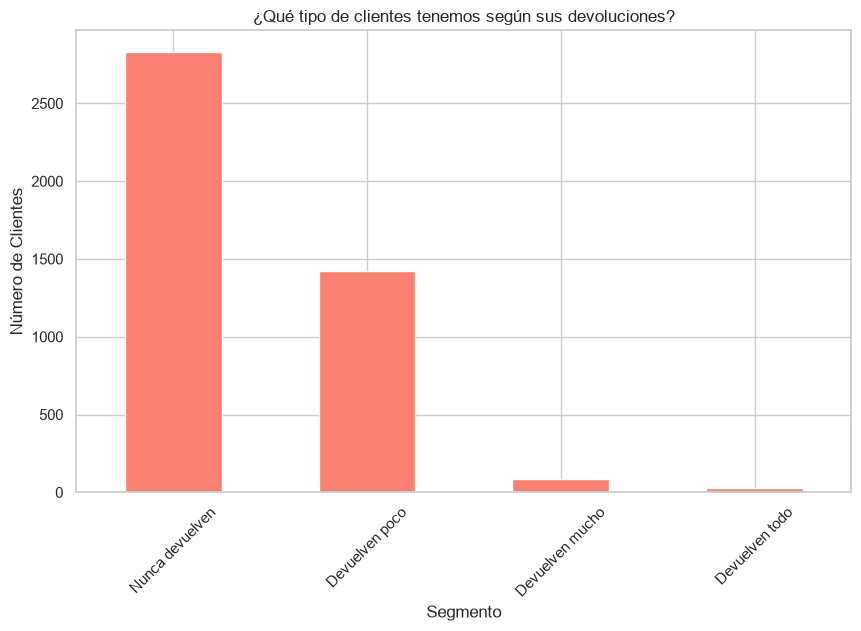

In [8]:
# Definimos grupos sencillos
df['segmento'] = pd.cut(df['return_rate'], 
                        bins=[-0.1, 0.0, 0.2, 0.8, 1.0], 
                        labels=['Nunca devuelven', 'Devuelven poco', 'Devuelven mucho', 'Devuelven todo'])

# Contamos cuántos clientes hay en cada uno
conteo = df['segmento'].value_counts().sort_index()

# Graficamos
plt.figure(figsize=(10, 6))
conteo.plot(kind='bar', color='salmon')
plt.title("¿Qué tipo de clientes tenemos según sus devoluciones?")
plt.xlabel("Segmento")
plt.ylabel("Número de Clientes")
plt.xticks(rotation=45)
plt.show()

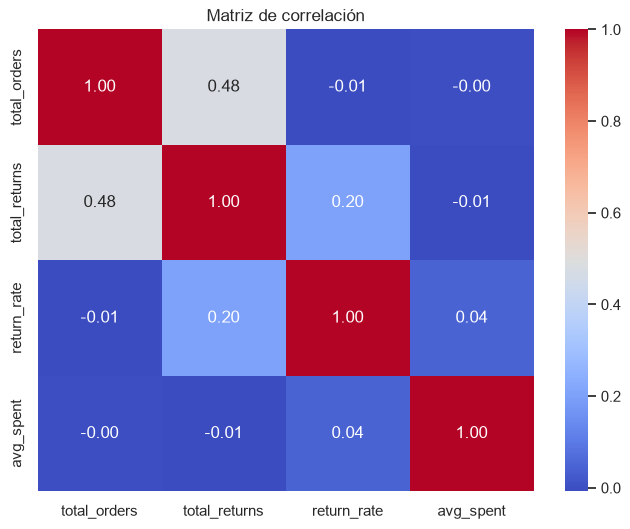

In [10]:
cols = ["total_orders", "total_returns", "return_rate", "avg_spent"]
plt.figure(figsize=(8, 6))
sns.heatmap(df[cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

## 3. Ingeniería del target

Esta etapa convierte la tasa de devolución en una variable binaria que representa riesgo. La definición usada es simple: un cliente se considera de alto riesgo cuando su `return_rate` supera el 15%.

In [ ]:
df["is_high_risk"] = (
    (df["total_returns"] >= 2) & (df["return_rate"] > 0.05)
).astype(int)

print(f"Proporción de clientes de alto riesgo: {df['is_high_risk'].mean():.2%}")

features = ["total_orders", "avg_spent"]
X = df[features]
y = df["is_high_risk"]
print(df[["return_rate", "is_high_risk"]].head())
print(f"Proporción de clientes de alto riesgo: {y.mean():.2%}")

Proporción de clientes de alto riesgo: 11.28%
   return_rate  is_high_risk
0     0.027027             0
1     0.001686             0
2     0.004587             0
3     0.000000             0
4     0.000000             0
Proporción de clientes de alto riesgo: 11.28%


## 4. Entrenamiento del modelo predictivo

Este bloque entrena un Random Forest para aprender patrones de comportamiento asociados a clientes de alto riesgo. El modelo usa las variables de comportamiento del cliente como insumo para la clasificación.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced_subsample")
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

## 5. Evaluación del modelo

La matriz de confusión permite verificar cuántas predicciones fueron correctas y cuántas se equivocaron, mientras que el reporte de clasificación resume métricas clave como precisión, recall y F1-score.

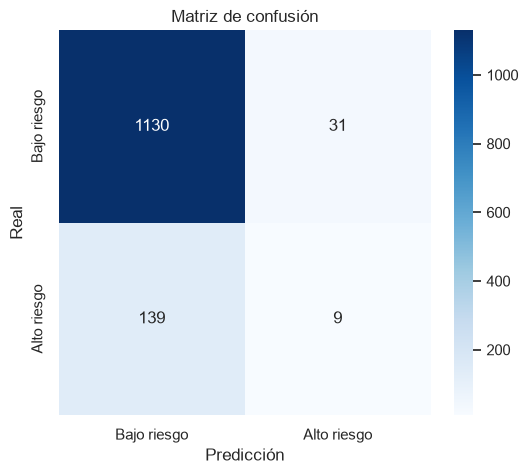


Reporte de clasificación:

              precision    recall  f1-score   support

 Bajo riesgo       0.89      0.97      0.93      1161
 Alto riesgo       0.23      0.06      0.10       148

    accuracy                           0.87      1309
   macro avg       0.56      0.52      0.51      1309
weighted avg       0.82      0.87      0.84      1309



In [13]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Bajo riesgo", "Alto riesgo"], yticklabels=["Bajo riesgo", "Alto riesgo"])
plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

print("\nReporte de clasificación:\n")
try:
    print(classification_report(y_test, y_pred, target_names=["Bajo riesgo", "Alto riesgo"], zero_division=0))
except ValueError:
    print(classification_report(y_test, y_pred, labels=[0], target_names=["Bajo riesgo"], zero_division=0))

## 6. Importancia de las variables

Este gráfico muestra qué características tuvieron mayor influencia en la predicción del modelo. Es especialmente útil para interpretar el comportamiento del algoritmo y comunicar los hallazgos de negocio.


Importancia de las características:
 avg_spent       0.596903
total_orders    0.403097
dtype: float64


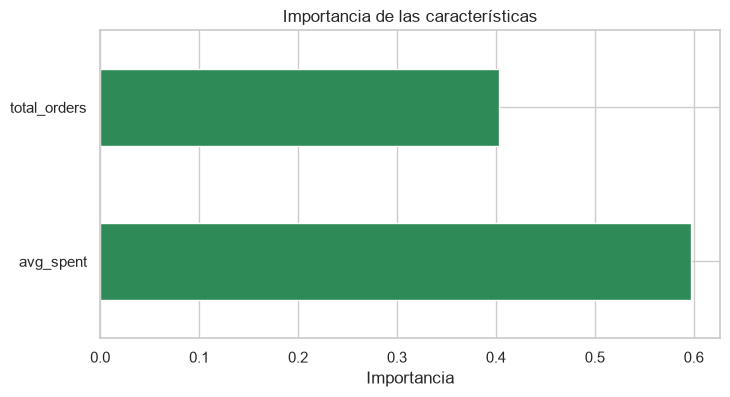

In [14]:
importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
print("\nImportancia de las características:\n", importance)
plt.figure(figsize=(8, 4))
importance.plot(kind="barh", color="seagreen")
plt.title("Importancia de las características")
plt.xlabel("Importancia")
plt.show()

In [15]:
# Asociar las predicciones con customer_id en el conjunto de prueba
predictions = pd.DataFrame({
    "customer_id": df.loc[X_test.index, "customer_id"],
    "total_orders": df.loc[X_test.index, "total_orders"],
    "total_returns": df.loc[X_test.index, "total_returns"],
    "return_rate": df.loc[X_test.index, "return_rate"],
    "avg_spent": df.loc[X_test.index, "avg_spent"],
    "predicted_high_risk": y_pred
}, index=X_test.index)

predicted_returners = predictions[predictions["predicted_high_risk"] == 1]

print(f"Clientes predichos como alto riesgo: {predicted_returners.shape[0]}")
print(predicted_returners.head(10))

Clientes predichos como alto riesgo: 40
      customer_id  total_orders  total_returns  return_rate  avg_spent  \
2236      18075.0           153             11     0.071895   3.557451   
1112      15814.0            74              2     0.027027   3.387973   
1760      14514.0            69              0     0.000000   3.159855   
968       14198.0            44              5     0.113636   4.646364   
2741      15216.0             2              0     0.000000   4.800000   
4131      16739.0            16              3     0.187500   3.012500   
299       17937.0            43              0     0.000000   3.473256   
3140      14440.0            55              0     0.000000   4.702364   
264       17680.0            11              0     0.000000   2.800000   
3510      16985.0           121              1     0.008264   4.183554   

      predicted_high_risk  
2236                    1  
1112                    1  
1760                    1  
968                     1  
2741 